# MLB Forecaster — Exploration

Scratch notebook for poking at the ingested data, Elo features, and trained models.

**Kernel:** select *MLB Forecaster* (the `mlb-forecaster` kernel) so `import mlb_forecaster` resolves.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlb_forecaster

# Resolve the repo root from this notebook's location (notebooks/ lives one level down).
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = REPO / "data"

print("mlb_forecaster", mlb_forecaster.__version__)
print("repo:", REPO)
%matplotlib inline
pd.set_option("display.max_columns", None)

mlb_forecaster 0.1.0
repo: /Users/asudharta01/google-ai-ml-mlb-predictions


## Load processed games

`data/processed/games_<season>.csv` holds the cleaned schedule + box-line data per season.

In [2]:
csvs = sorted((DATA / "processed").glob("games_*.csv"))
games = pd.concat((pd.read_csv(p, parse_dates=["date"]) for p in csvs), ignore_index=True)
print(f"{len(games):,} games across seasons {games.season.min()}-{games.season.max()}")
games.head()

20,711 games across seasons 2017-2025


,game_pk,date,season,game_type,home_team,away_team,home_score,away_score,status,home_pitcher_id,away_pitcher_id,home_pitcher,away_pitcher,venue_id,double_header,home_outs,home_hits,home_runs,home_earned_runs,home_walks,home_strikeouts,home_home_runs,away_outs,away_hits,away_runs,away_earned_runs,away_walks,away_strikeouts,away_home_runs,playoff,home_starter_id,away_starter_id
0,490099,2017-04-02,2017,R,STL,CHC,4.0,3.0,Final,593372.0,452657.0,Carlos Martinez,Jon Lester,2889.0,N,22.0,6.0,0.0,0.0,0.0,10.0,0.0,15.0,7.0,1.0,1.0,2.0,7.0,0.0,False,593372.0,452657.0
1,490106,2017-04-02,2017,R,TB,NYY,7.0,3.0,Final,502042.0,547888.0,Chris Archer,Masahiro Tanaka,12.0,N,21.0,7.0,2.0,2.0,1.0,5.0,0.0,8.0,8.0,7.0,7.0,2.0,3.0,2.0,False,502042.0,547888.0
2,490110,2017-04-02,2017,R,AZ,SF,6.0,5.0,Final,425844.0,518516.0,Zack Greinke,Madison Bumgarner,15.0,N,15.0,4.0,2.0,2.0,2.0,4.0,1.0,21.0,6.0,3.0,3.0,0.0,11.0,1.0,False,425844.0,518516.0
3,490098,2017-04-03,2017,R,NYM,ATL,6.0,0.0,Final,592789.0,527054.0,Noah Syndergaard,Julio Teheran,3289.0,N,18.0,5.0,0.0,0.0,0.0,7.0,0.0,18.0,4.0,0.0,0.0,3.0,6.0,0.0,False,592789.0,527054.0
4,490100,2017-04-03,2017,R,TEX,CLE,5.0,8.0,Final,506433.0,446372.0,Yu Darvish,Corey Kluber,13.0,N,19.0,4.0,4.0,4.0,5.0,4.0,1.0,18.0,6.0,5.0,5.0,3.0,6.0,3.0,False,506433.0,446372.0


In [3]:
# Hits per game made by each season's champion (the team that won the final playoff game).
played = games[games.home_score.notna()].copy()

# Champion = winner of the latest-dated playoff game in each season.
finals = played[played.playoff].sort_values("date").groupby("season").tail(1)
champions = {
    row.season: (row.home_team if row.home_score > row.away_score else row.away_team)
    for row in finals.itertuples()
}

# Long form: one row per (team, game) with the hits that team recorded.
home = played[["season", "home_team", "home_hits"]].rename(columns={"home_team": "team", "home_hits": "hits"})
away = played[["season", "away_team", "away_hits"]].rename(columns={"away_team": "team", "away_hits": "hits"})
team_games = pd.concat([home, away], ignore_index=True)

rows = []
for season, champ in champions.items():
    tg = team_games[(team_games.season == season) & (team_games.team == champ)]
    rows.append({"season": season, "champion": champ, "games": len(tg), "hits_per_game": tg.hits.mean()})

champ_hits = pd.DataFrame(rows).set_index("season")
champ_hits

,champion,games,hits_per_game
season,,,
2017,HOU,180,5.044444
2018,BOS,176,4.812500
2019,WSH,179,5.044693
2020,LAD,78,3.641026
2021,ATL,177,4.327684
2022,HOU,175,4.554286
2023,TEX,179,5.022346
2024,LAD,178,4.449438
2025,LAD,179,3.966480


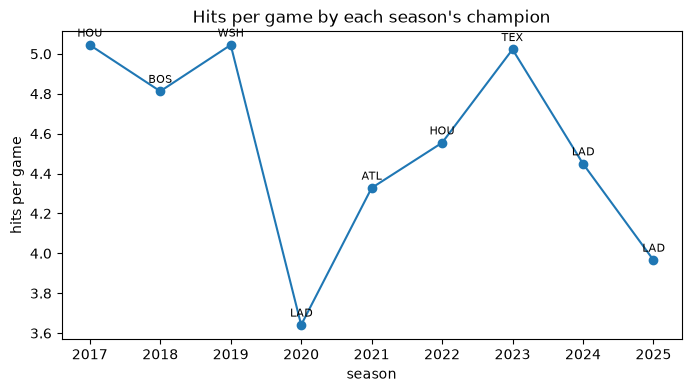

In [4]:
ax = champ_hits["hits_per_game"].plot(marker="o", figsize=(8, 4), title="Hits per game by each season's champion")
ax.set_xlabel("season")
ax.set_ylabel("hits per game")
# Annotate each point with the champion's team abbreviation.
for season, row in champ_hits.iterrows():
    ax.annotate(row["champion"], (season, row["hits_per_game"]),
                textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)
plt.show()

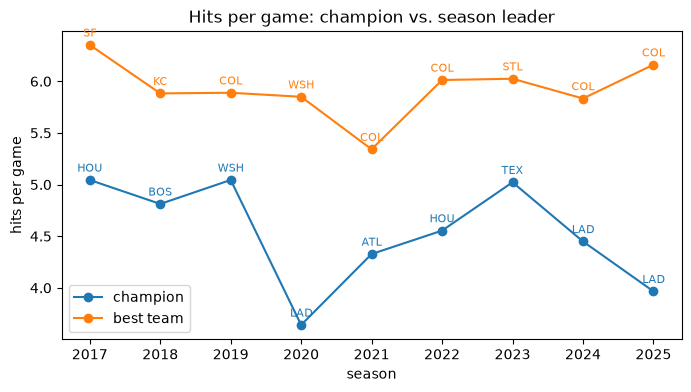

In [5]:
# For each season, the team with the highest hits per game (any team, not just the champion).
team_hpg = team_games.groupby(["season", "team"])["hits"].mean().reset_index()
best = team_hpg.loc[team_hpg.groupby("season")["hits"].idxmax()].set_index("season")

# Plot the champion's hits per game alongside the season-leading team's.
ax = champ_hits["hits_per_game"].plot(marker="o", color="C0", figsize=(8, 4),
                                      title="Hits per game: champion vs. season leader", label="champion")
best["hits"].plot(ax=ax, marker="o", color="C1", label="best team")
ax.set_xlabel("season")
ax.set_ylabel("hits per game")
ax.legend()

# Label the champion points.
for season, row in champ_hits.iterrows():
    ax.annotate(row["champion"], (season, row["hits_per_game"]),
                textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8, color="C0")
# Label the season-leader points.
for season, row in best.iterrows():
    ax.annotate(row["team"], (season, row["hits"]),
                textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8, color="C1")
plt.show()

## Config

All tunables live in `config.yaml`. Load it through the package so you see the same view the pipeline does.

In [ ]:
from mlb_forecaster.config import load_config

cfg = load_config(REPO / "config.yaml")
cfg

## Scratch

Inspect trained models in `data/models/`, run the Elo engine, plot calibration, etc.